In [9]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import interpax
import numpy as np

from models import f_lin_2d

<function models.f_lin_2d(xy, theta)>

In [78]:
def spline_model(xy, theta):

    x, y = xy.T
    nx, ny = theta.shape
    xx = jnp.linspace(jnp.min(x), jnp.max(x), nx)
    yy = jnp.linspace(jnp.min(y), jnp.max(y), ny)
    
    return interpax.interp2d(x, y, xx, yy, theta.reshape(nx, ny))

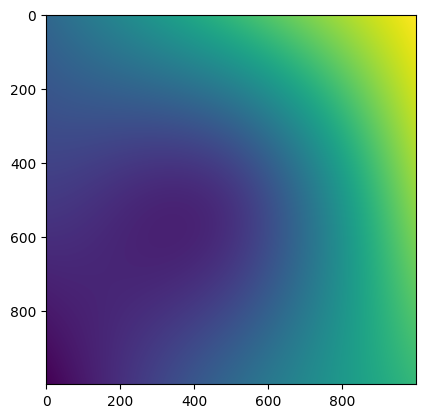

In [82]:
theta = zz.reshape(3, 3)
theta[1, 1] = -20
model = spline_model(xy, theta)

xhi, yhi = np.linspace(-10, 10, 1000), np.linspace(-10, 10, 1000)
xhiyhi = np.concatenate(np.array(np.meshgrid(xhi, yhi)).T, axis=0)
plt.imshow(spline_model(xhiyhi, theta).reshape(1000, 1000))

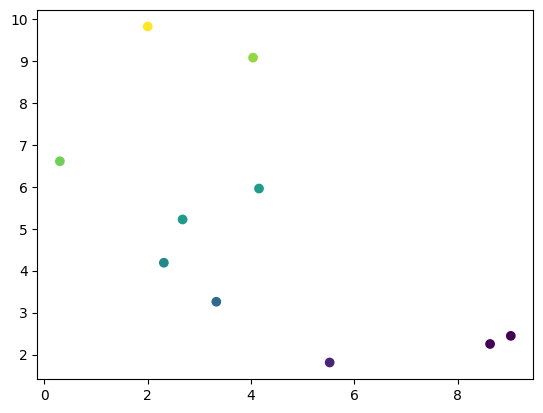

In [75]:
xx = np.linspace(-10, 10, 3)
yy = np.linspace(-10, 10, 3)

x = np.random.rand(10) * 10
y = np.random.rand(10) * 10

xy = np.vstack([x, y]).T
xxyy = np.concatenate(np.array(np.meshgrid(xx, yy)).T, axis=0)

z = f_lin_2d(xy, [1, -1, 2])
zz = f_lin_2d(xxyy, [1, -1, 2])

plt.scatter(x, y, c=z)

In [42]:
xx.shape

(10,)

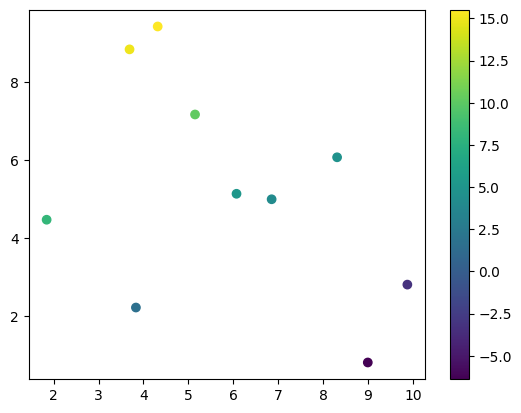

In [38]:
model_vals = interpax.interp2d(x, y, xx, yy, zz.reshape(10, 10))
plt.scatter(x, y, c=model_vals)
plt.colorbar()

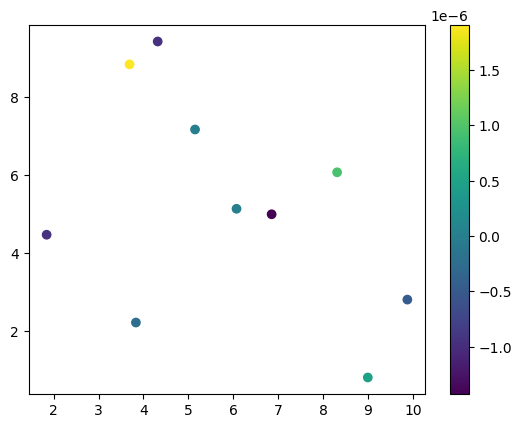

In [37]:
plt.scatter(x, y, c=model_vals - z)
plt.colorbar()